In [9]:
import requests
import geopandas as gpd
import os

# Descomprimir y leer el shapefile 2024
import zipfile

ruta_raw = "C:\\Users\\kenpa\\OneDrive\\Desktop\\FORMACION\\colombia-mercado-inmobiliario\\data\\raw\\bogota\\"
ruta_external = "C:\\Users\\kenpa\\OneDrive\\Desktop\\FORMACION\\colombia-mercado-inmobiliario\\data\\external\\bogota\\"
os.makedirs(ruta_external, exist_ok=True)

# Descomprime todos los ZIPs
for archivo in os.listdir(ruta_raw):
    if archivo.endswith(".zip"):
        with zipfile.ZipFile(ruta_raw + archivo, 'r') as z:
            z.extractall(ruta_external + archivo.replace(".zip", ""))
            print(f"✓ Extraído: {archivo}")

print("\nArchivos disponibles:")
for root, dirs, files in os.walk(ruta_external):
    for f in files:
        print(f"  {os.path.join(root, f)}")

✓ Extraído: valor_referencia_m_2024.zip
✓ Extraído: valor_ref_2022.zip
✓ Extraído: valor_ref_m_2021.zip

Archivos disponibles:
  C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota\valor_referencia_m_2024\Valor_Ref_M_2024.cpg
  C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota\valor_referencia_m_2024\Valor_Ref_M_2024.dbf
  C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota\valor_referencia_m_2024\Valor_Ref_M_2024.prj
  C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota\valor_referencia_m_2024\Valor_Ref_M_2024.sbn
  C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota\valor_referencia_m_2024\Valor_Ref_M_2024.sbx
  C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota\valor_referencia_m_2024\Valor_Ref_M_2024.shp
  C:\Users\kenpa\OneDrive\Desktop

In [12]:
import geopandas as gpd
import os

ruta_external = r"C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota"

shapefiles = []
for root, dirs, files in os.walk(ruta_external):
    for f in files:
        if f.endswith(".shp"):
            shapefiles.append(os.path.join(root, f))

print(f"Shapefiles encontrados: {len(shapefiles)}\n")

for shp in shapefiles:
    print(f"{'='*55}")
    print(f"Archivo : {shp}")
    try:
        # engine='pyogrio' evita el problema de fiona
        gdf = gpd.read_file(shp, engine="pyogrio")
        print(f"Filas   : {len(gdf):,}")
        print(f"CRS     : {gdf.crs}")
        print(f"Columnas: {gdf.columns.tolist()}")
        print(f"Muestra :")
        print(gdf.drop(columns='geometry').head(3).to_string())
    except Exception as e:
        print(f"Error al leer: {e}")
    print()

Shapefiles encontrados: 3

Archivo : C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota\valor_referencia_m_2024\Valor_Ref_M_2024.shp
Filas   : 42,036
CRS     : EPSG:4326
Columnas: ['OBJECTID', 'ManCodigo', 'ValRef', 'Vigencia', 'SHAPE_Leng', 'Shape_Le_1', 'Shape_Area', 'geometry']
Muestra :
   OBJECTID  ManCodigo     ValRef   Vigencia  SHAPE_Leng  Shape_Le_1    Shape_Area
0         1  002521099   629000.0 2024-01-01  222.357236    0.002009  1.200827e-07
1         2  008530012  4250000.0 2024-01-01  342.777885    0.003094  5.835636e-07
2         3  008417066  6400000.0 2024-01-01  331.098220    0.002987  5.228409e-07

Archivo : C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota\valor_ref_2022\Valor_ref_2022\Valor_ref_2022.shp
Filas   : 41,584
CRS     : EPSG:4326
Columnas: ['OBJECTID', 'MANCODIGO', 'V_REF', 'ANO', 'SHAPE_Leng', 'SHAPE_Area', 'geometry']
Muestra :
   OBJECTID  MANCODIGO      V_REF        A

In [14]:
# ============================================================
# 01_exploracion_eda.ipynb
# Exploración inicial de datos de valor de referencia por m²
# Fuente: Catastro Distrital UAECD — Bogotá D.C.
# ============================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

# Estilo visual consistente para todo el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"

RUTA = r"C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota"
RUTA_PROCESSED = r"C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\processed"
os.makedirs(RUTA_PROCESSED, exist_ok=True)

print("✔️ Librerías cargadas correctamente")
print(f"🗺️ geopandas : {gpd.__version__}")
print(f"🐼 pandas    : {pd.__version__}")

✔️ Librerías cargadas correctamente
🗺️ geopandas : 0.14.0
🐼 pandas    : 2.2.0


In [ ]:
# ── Carga individual ──────────────────────────────────────────
gdf_2024 = gpd.read_file(
    os.path.join(RUTA, "valor_referencia_m_2024", "Valor_Ref_M_2024.shp"),
    engine="pyogrio"
)
gdf_2022 = gpd.read_file(
    os.path.join(RUTA, "valor_ref_2022", "Valor_ref_2022", "Valor_ref_2022.shp"),
    engine="pyogrio"
)
gdf_2021 = gpd.read_file(
    os.path.join(RUTA, "valor_ref_m_2021", "Valor_Ref_M_2021.shp"),
    engine="pyogrio"
)

# ── Estandarizar columnas — cada año tiene nombres distintos ──
# Creamos un esquema común: manzana_cod | valor_ref_m2 | año | geometry

def estandarizar(gdf, col_codigo, col_valor, año):
    """Normaliza columnas a esquema común del proyecto"""
    gdf = gdf[[col_codigo, col_valor, "geometry"]].copy()
    gdf.columns = ["manzana_cod", "valor_ref_m2", "geometry"]
    gdf["año"] = año
    gdf["manzana_cod"] = gdf["manzana_cod"].astype(str).str.strip()
    gdf["valor_ref_m2"] = pd.to_numeric(gdf["valor_ref_m2"], errors="coerce")
    return gdf

gdf_2024 = estandarizar(gdf_2024, "ManCodigo", "ValRef",  2024)
gdf_2022 = estandarizar(gdf_2022, "MANCODIGO", "V_REF",   2022)
gdf_2021 = estandarizar(gdf_2021, "MANCODIGO", "V_REF",   2021)

# ── Unir en un solo GeoDataFrame ──────────────────────────────
gdf = pd.concat([gdf_2021, gdf_2022, gdf_2024], ignore_index=True)
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs="EPSG:4326")

print(f"Dataset unificado: {len(gdf):,} registros | {gdf['año'].unique()} años")
print(f"CRS: {gdf.crs}")
print(f"\nColumnas finales: {gdf.columns.tolist()}")
gdf.head(3)

Dataset unificado: 127,578 registros | [2021 2022 2024] años
CRS: EPSG:4326

Columnas finales: ['manzana_cod', 'valor_ref_m2', 'geometry', 'año']


,manzana_cod,valor_ref_m2,geometry,año
0,007401035,3100000.0,"POLYGON ((-74.06083 4.67097, -74.06087 4.67077...",2021
1,002592025,590000.0,"POLYGON ((-74.11902 4.49012, -74.11905 4.49004...",2021
2,007403017,3200000.0,"POLYGON ((-74.06349 4.66352, -74.06355 4.66342...",2021


In [16]:
# ── Reporte de calidad por año ────────────────────────────────
print("=" * 55)
print("REPORTE DE CALIDAD DE DATOS")
print("=" * 55)

for año in sorted(gdf["año"].unique()):
    sub = gdf[gdf["año"] == año]
    nulos = sub["valor_ref_m2"].isna().sum()
    ceros = (sub["valor_ref_m2"] == 0).sum()
    negativos = (sub["valor_ref_m2"] < 0).sum()
    pct_nulos = nulos / len(sub) * 100

    print(f"\nAño {año} — {len(sub):,} manzanas")
    print(f"  Nulos         : {nulos:,}  ({pct_nulos:.2f}%)")
    print(f"  Ceros         : {ceros:,}")
    print(f"  Negativos     : {negativos:,}")
    print(f"  Valor mín     : ${sub['valor_ref_m2'].min():,.0f}")
    print(f"  Valor máx     : ${sub['valor_ref_m2'].max():,.0f}")
    print(f"  Valor mediana : ${sub['valor_ref_m2'].median():,.0f}")
    print(f"  Valor media   : ${sub['valor_ref_m2'].mean():,.0f}")

print("\n" + "=" * 55)

# Geometrías inválidas
geom_invalidas = (~gdf.geometry.is_valid).sum()
print(f"Geometrías inválidas: {geom_invalidas:,}")

REPORTE DE CALIDAD DE DATOS

Año 2021 — 43,958 manzanas
  Nulos         : 0  (0.00%)
  Ceros         : 2,371
  Negativos     : 0
  Valor mín     : $0
  Valor máx     : $28,500,000
  Valor mediana : $1,800,000
  Valor media   : $1,865,565

Año 2022 — 41,584 manzanas
  Nulos         : 0  (0.00%)
  Ceros         : 0
  Negativos     : 0
  Valor mín     : $8,300
  Valor máx     : $28,500,000
  Valor mediana : $1,900,000
  Valor media   : $1,971,835

Año 2024 — 42,036 manzanas
  Nulos         : 0  (0.00%)
  Ceros         : 0
  Negativos     : 0
  Valor mín     : $3,800
  Valor máx     : $28,500,000
  Valor mediana : $2,150,000
  Valor media   : $2,220,722

Geometrías inválidas: 19


In [ ]:
# ── Limpieza ──────────────────────────────────────────────────
filas_antes = len(gdf)

# 1. Eliminar nulos en valor
gdf = gdf[gdf["valor_ref_m2"].notna()]

# 2. Eliminar valores <= 0 (sin sentido económico)
gdf = gdf[gdf["valor_ref_m2"] > 0]

# 3. Eliminar outliers extremos con método IQR por año
# (conservamos el 99.5% — no queremos perder zonas premium reales)
def remover_outliers_iqr(df, col, factor=4.0):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - factor * IQR) & (df[col] <= Q3 + factor * IQR)]

gdf = gdf.groupby("año", group_keys=False).apply(
    lambda x: remover_outliers_iqr(x, "valor_ref_m2")
)
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs="EPSG:4326")

# 4. Reparar geometrías inválidas
gdf["geometry"] = gdf["geometry"].buffer(0)

filas_despues = len(gdf)
print(f"Filas antes  : {filas_antes:,}")
print(f"Filas después: {filas_despues:,}")
print(f"Eliminadas   : {filas_antes - filas_despues:,} ({(filas_antes-filas_despues)/filas_antes*100:.2f}%)")
print("✔️ Limpieza completada")

Filas antes  : 125,003
Filas después: 125,003
Eliminadas   : 0 (0.00%)
✓ Limpieza completada


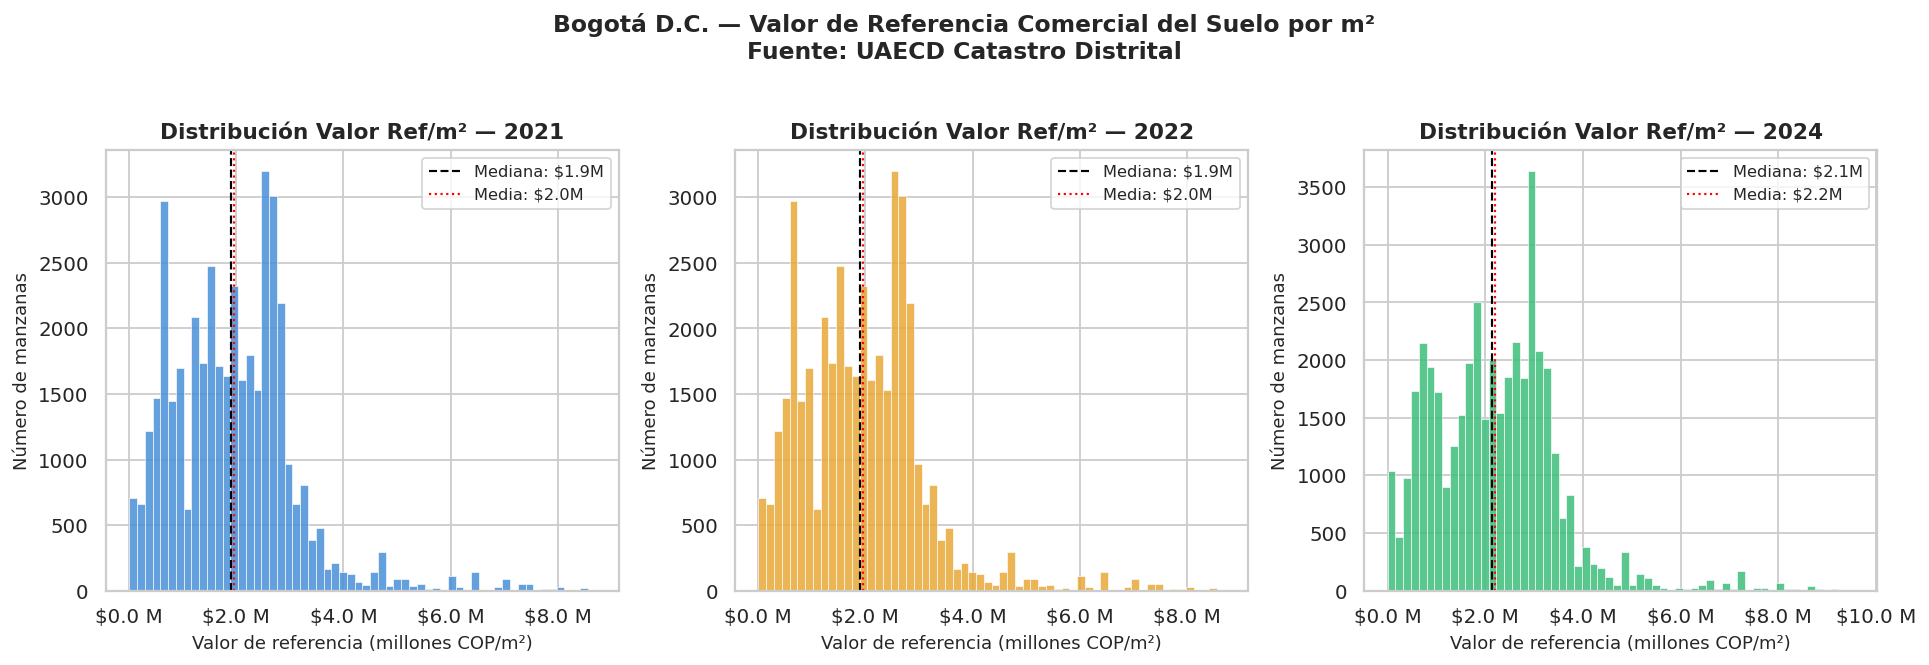

✔️ Gráfica guardada en reports/figures/


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colores = {2021: "#4A90D9", 2022: "#E8A838", 2024: "#3DBE7A"}

for ax, año in zip(axes, [2021, 2022, 2024]):
    sub = gdf[gdf["año"] == año]["valor_ref_m2"]
    ax.hist(sub / 1_000_000, bins=60, color=colores[año],
            edgecolor="white", linewidth=0.4, alpha=0.85)

    # Líneas de referencia
    ax.axvline(sub.median() / 1_000_000, color="black",
               linestyle="--", linewidth=1.2, label=f"Mediana: ${sub.median()/1e6:.1f}M")
    ax.axvline(sub.mean() / 1_000_000, color="red",
               linestyle=":", linewidth=1.2, label=f"Media: ${sub.mean()/1e6:.1f}M")

    ax.set_title(f"Distribución Valor Ref/m² — {año}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Valor de referencia (millones COP/m²)", fontsize=10)
    ax.set_ylabel("Número de manzanas", fontsize=10)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1f M"))

plt.suptitle("Bogotá D.C. — Valor de Referencia Comercial del Suelo por m²\nFuente: UAECD Catastro Distrital",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(
    r"C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\reports\figures\01_distribucion_valor_m2.png",
    bbox_inches="tight", dpi=150
)
plt.show()
print("✔️ Gráfica guardada en reports/figures/")

KPI #1 — Evolución del valor de referencia mediano (COP/m²)📈
  2021  |  Mediana: $   1,900,000  |  ⬆️   (base)
  2022  |  Mediana: $   1,900,000  |  ⬆️   +0.0%
  2024  |  Mediana: $   2,150,000  |  ⬆️   +13.2%


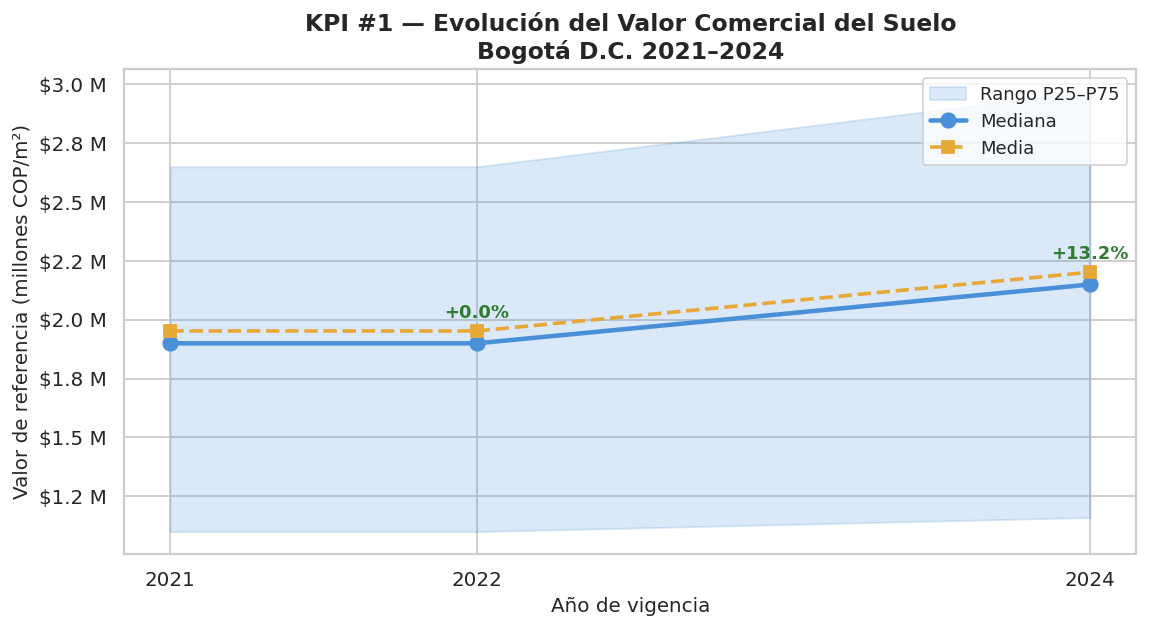

In [24]:
# ── KPI #1: Variación del valor mediano por año ───────────────
resumen = gdf.groupby("año")["valor_ref_m2"].agg(
    mediana="median",
    media="mean",
    manzanas="count",
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
).reset_index()

# Calcular variación % respecto al año anterior
resumen["var_pct_mediana"] = resumen["mediana"].pct_change() * 100

print("KPI #1 — Evolución del valor de referencia mediano (COP/m²)📈")
print("=" * 58)
for _, row in resumen.iterrows():
    var = f"  {row['var_pct_mediana']:+.1f}%" if not pd.isna(row["var_pct_mediana"]) else "  (base)"
    print(f"  {int(row['año'])}  |  Mediana: ${row['mediana']:>12,.0f}  |  ⬆️ {var}")
print("=" * 58)

# Gráfica
fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(resumen["año"], resumen["p25"] / 1e6,
                resumen["p75"] / 1e6, alpha=0.2, color="#4A90D9", label="Rango P25–P75")
ax.plot(resumen["año"], resumen["mediana"] / 1e6,
        marker="o", color="#4A90D9", linewidth=2.5, markersize=8, label="Mediana")
ax.plot(resumen["año"], resumen["media"] / 1e6,
        marker="s", color="#E8A838", linewidth=2, linestyle="--",
        markersize=7, label="Media")

# Anotar variación %
for _, row in resumen.iterrows():
    if not pd.isna(row["var_pct_mediana"]):
        ax.annotate(f"{row['var_pct_mediana']:+.1f}%",
                    xy=(row["año"], row["mediana"] / 1e6),
                    xytext=(0, 14), textcoords="offset points",
                    ha="center", fontsize=10, fontweight="bold",
                    color="#2E7D32")

ax.set_xticks([2021, 2022, 2024])
ax.set_xlabel("Año de vigencia", fontsize=11)
ax.set_ylabel("Valor de referencia (millones COP/m²)", fontsize=11)
ax.set_title("KPI #1 — Evolución del Valor Comercial del Suelo\nBogotá D.C. 2021–2024",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1f M"))

plt.tight_layout()
plt.savefig(
    r"C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\reports\figures\02_evolucion_kpi1.png",
    bbox_inches="tight", dpi=150
)
plt.show()

📈
✔️

In [25]:
# ── Guardar el dataset limpio y unificado ─────────────────────
ruta_salida = os.path.join(RUTA_PROCESSED, "bogota_valor_ref_unificado.gpkg")

gdf.to_file(ruta_salida, driver="GPKG", engine="pyogrio")

print(f"✔️ Dataset procesado guardado:")
print(f"  {ruta_salida}")
print(f"  {len(gdf):,} registros | {gdf['año'].nunique()} años | formato GeoPackage")
print(f"\nEste archivo es la entrada de todos los notebooks siguientes.")

✔️ Dataset procesado guardado:
  C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\processed\bogota_valor_ref_unificado.gpkg
  125,003 registros | 3 años | formato GeoPackage

Este archivo es la entrada de todos los notebooks siguientes.
